# Phase 1 : Exploration et Analyse du Dataset HAM10000 (EDA)

**Objectif :** Ce notebook a pour but d'analyser la structure des données brutes, de quantifier le déséquilibre des classes, de détecter d'éventuelles fuites de données (Data Leakage) et d'explorer les corrélations cliniques avant la phase de modélisation.

## 1. Initialisation et Audit global des données (Sanity Check)
Importation des librairies standards pour la manipulation de données et la visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration de base pour l'esthétique des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Librairies importées avec succès !")

Librairies importées avec succès !


### Chargement des métadonnées
Le fichier `HAM10000_metadata.csv` contient toutes les informations cliniques associées aux images. Vérifions si le chemin d'accès est correct.

In [3]:
# Chemin relatif depuis le dossier /notebooks vers /data/raw
csv_path = '../data/raw/HAM10000_metadata.csv'

# Chargement du dataframe
df = pd.read_csv(csv_path)

# Affichage des 5 premières lignes
display(df.head())

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


### Inspection des dimensions et des types
Il est crucial de vérifier la taille exacte du dataset et le typage de nos variables (numériques vs textuelles) pour anticiper le prétraitement.

In [3]:
print(f"Dimensions du dataset : {df.shape[0]} images et {df.shape[1]} colonnes.\n")
print("Informations sur les colonnes :")
df.info()

Dimensions du dataset : 10015 images et 7 colonnes.

Informations sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


### Détection des valeurs manquantes (NaN)
En milieu médical, les données sont rarement parfaites. Identifions les trous dans notre dataset pour décider si nous devons les supprimer ou les imputer.

In [10]:
# Calcul des valeurs manquantes et de leur pourcentage
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Création d'un petit tableau récapitulatif
missing_data = pd.DataFrame({'Valeurs Manquantes': missing_values, 'Pourcentage (%)': missing_percentage})
display(missing_data[missing_data['Valeurs Manquantes'] > 0])

# Vérification rapide sur l'âge
if 'age' in df.columns and df['age'].isnull().sum() > 0:
    print(f"\nAttention : La colonne 'age' contient {df['age'].isnull().sum()} valeurs manquantes.")

,Valeurs Manquantes,Pourcentage (%)
age,57,0.569146



Attention : La colonne 'age' contient 57 valeurs manquantes.


## 2. Analyse de la Variable Cible (Le Déséquilibre)

La colonne `dx` (Diagnostic) est notre variable cible (ce que nos modèles devront prédire). Le dataset HAM10000 contient 7 types de lésions cutanées. Nous allons quantifier leur répartition pour comprendre la sévérité du déséquilibre, en nous concentrant particulièrement sur le ratio entre les Nævus (nv - grains de beauté bénins) et les Mélanomes (mel - cancer mortel).

In [5]:
# Comptage des occurrences pour chaque classe
class_counts = df['dx'].value_counts()
class_percentages = df['dx'].value_counts(normalize=True) * 100

# Création d'un DataFrame de synthèse pour un affichage propre
target_summary = pd.DataFrame({
    'Nombre d\'images': class_counts, 
    'Pourcentage (%)': class_percentages.round(2)
})

display(target_summary)

# Calcul du ratio spécifique entre la classe majoritaire (nv) et la cible (mel)
count_nv = class_counts.get('nv', 0)
count_mel = class_counts.get('mel', 0)

print(f"\n--- Focus sur le ratio Nævus / Mélanome ---")
print(f"Nombre de Nævus (nv) : {count_nv}")
print(f"Nombre de Mélanomes (mel) : {count_mel}")
if count_mel > 0:
    ratio = count_nv / count_mel
    print(f"Ratio : Il y a {ratio:.1f} fois plus d'images de Nævus que de Mélanomes.")

,Nombre d'images,Pourcentage (%)
dx,,
nv,6705,66.95
mel,1113,11.11
bkl,1099,10.97
bcc,514,5.13
akiec,327,3.27
vasc,142,1.42
df,115,1.15



--- Focus sur le ratio Nævus / Mélanome ---
Nombre de Nævus (nv) : 6705
Nombre de Mélanomes (mel) : 1113
Ratio : Il y a 6.0 fois plus d'images de Nævus que de Mélanomes.


### Visualisation et Sauvegarde du Graphique

Pour illustrer ce déséquilibre dans notre rapport de PFE, nous allons générer un graphique en barres. Nous utiliserons le dictionnaire officiel des abréviations médicales pour rendre le graphique compréhensible pour un jury non-dermatologue.

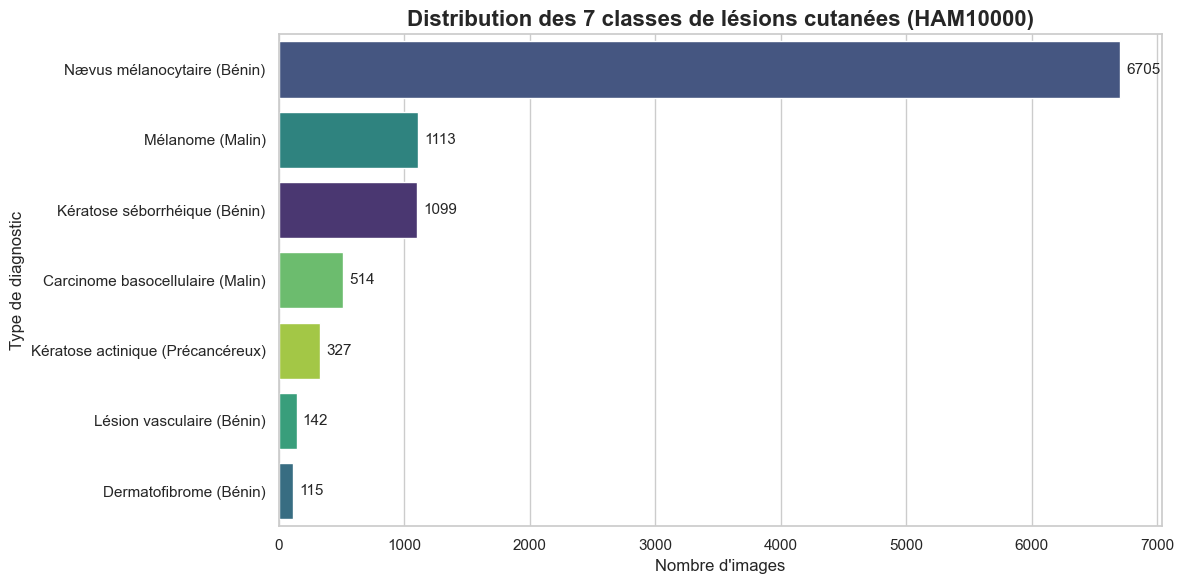

Graphique sauvegardé avec succès dans le dossier : reports/figures/distribution_classes.png


In [6]:
# Dictionnaire complet des lésions (pour un graphique plus lisible)
lesion_names = {
    'nv': 'Nævus mélanocytaire (Bénin)',
    'mel': 'Mélanome (Malin)',
    'bkl': 'Kératose séborrhéique (Bénin)',
    'bcc': 'Carcinome basocellulaire (Malin)',
    'akiec': 'Kératose actinique (Précancéreux)',
    'vasc': 'Lésion vasculaire (Bénin)',
    'df': 'Dermatofibrome (Bénin)'
}

# Ajout d'une colonne avec le nom complet
df['dx_name'] = df['dx'].map(lesion_names)

# Création du dossier reports/figures s'il n'existe pas encore
os.makedirs('../reports/figures', exist_ok=True)

# Création du graphique
plt.figure(figsize=(12, 6))
sns.countplot(
    y='dx_name', 
    data=df, 
    order=df['dx_name'].value_counts().index, 
    palette='viridis',
    hue='dx_name',
    legend=False
)

plt.title('Distribution des 7 classes de lésions cutanées (HAM10000)', fontsize=16, fontweight='bold')
plt.xlabel('Nombre d\'images', fontsize=12)
plt.ylabel('Type de diagnostic', fontsize=12)

# Ajout des valeurs numériques au bout de chaque barre
for index, value in enumerate(df['dx_name'].value_counts()):
    plt.text(value + 50, index, str(value), va='center', fontsize=11)

# Sauvegarde du graphique au format PNG pour le rapport final
plt.tight_layout()
plt.savefig('../reports/figures/distribution_classes.png', dpi=300)
plt.show()

print("Graphique sauvegardé avec succès dans le dossier : reports/figures/distribution_classes.png")

## 3. Les pièges du HAM10000 : Fuite de données et Vérité terrain

### 3.1. Le piège du `lesion_id` (Data Leakage)
Le dataset contient 10 015 images, mais correspond-il à 10 015 lésions distinctes ? Souvent, en dermatologie, un même grain de beauté est pris en photo plusieurs fois (gros plan, angle différent, recul). 
Si une image de la lésion A se retrouve dans le set d'entraînement, et une autre image de la *même* lésion A se retrouve dans le set de test, notre modèle va "tricher" : il reconnaîtra la photo (la peau du patient, l'éclairage) au lieu de reconnaître la maladie. C'est ce qu'on appelle la **fuite de données (Data Leakage)**.

In [7]:
# Nombre total d'images vs Nombre de lésions uniques
total_images = len(df)
unique_lesions = df['lesion_id'].nunique()

print(f"Nombre total d'images : {total_images}")
print(f"Nombre de lésions uniques : {unique_lesions}")
print(f"Différence : {total_images - unique_lesions} images sont des doublons d'une même lésion.\n")

# Calculons combien de lésions ont plusieurs images
lesion_counts = df['lesion_id'].value_counts()
# print(lesion_counts)
lesions_with_multiple_images = lesion_counts[lesion_counts > 1]

print(f"--- Analyse des doublons ---")
print(f"Nombre de lésions photographiées 1 seule fois : {len(lesion_counts[lesion_counts == 1])}")
print(f"Nombre de lésions photographiées 2 fois ou plus : {len(lesions_with_multiple_images)}")

# Conclusion stratégique imprimée directement dans la console
print("\n⚠️ DÉCISION ARCHITECTURALE :")
print("Lors de la séparation Train/Test (Notebook 02), nous NE POURRONS PAS utiliser un simple 'train_test_split'.")
print("Nous devrons regrouper les données par 'lesion_id' (ex: GroupKFold) pour qu'une même lésion ne traverse jamais la frontière Train/Test.")

Nombre total d'images : 10015
Nombre de lésions uniques : 7470
Différence : 2545 images sont des doublons d'une même lésion.

--- Analyse des doublons ---
Nombre de lésions photographiées 1 seule fois : 5514
Nombre de lésions photographiées 2 fois ou plus : 1956

⚠️ DÉCISION ARCHITECTURALE :
Lors de la séparation Train/Test (Notebook 02), nous NE POURRONS PAS utiliser un simple 'train_test_split'.
Nous devrons regrouper les données par 'lesion_id' (ex: GroupKFold) pour qu'une même lésion ne traverse jamais la frontière Train/Test.


### 3.2. La qualité de la Vérité Terrain (`dx_type`)
Comment les médecins ont-ils su de quelle maladie il s'agissait ? La colonne `dx_type` nous indique la méthode de validation.
* **histo** : Histopathologie (Biopsie au microscope - Fiabilité 100%)
* **consensus** : Accord entre plusieurs experts
* **confocal** : Microscopie confocale
* **follow_up** : Suivi clinique du patient

Il est important de savoir sur quelle proportion de "certitude absolue" notre modèle va s'entraîner.

,Nombre,Pourcentage (%)
dx_type,,
histo,5340,53.32
follow_up,3704,36.98
consensus,902,9.01
confocal,69,0.69


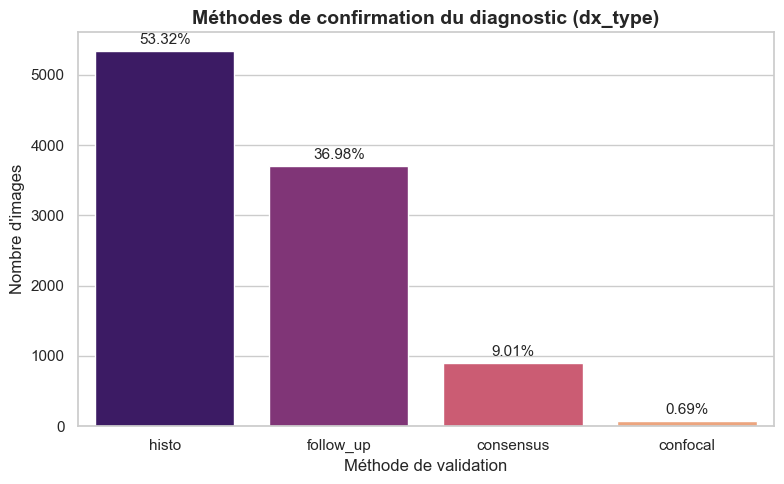


Focus Sécurité : Sur les 1113 mélanomes du dataset, 1113 ont été confirmés par biopsie (histo).
Soit 100.0% de certitude absolue sur notre classe la plus dangereuse.


In [8]:
# Analyse de la méthode de diagnostic
dx_type_counts = df['dx_type'].value_counts()
dx_type_percentages = df['dx_type'].value_counts(normalize=True) * 100

dx_summary = pd.DataFrame({
    'Nombre': dx_type_counts, 
    'Pourcentage (%)': dx_type_percentages.round(2)
})

display(dx_summary)

# Visualisation rapide
plt.figure(figsize=(8, 5))
sns.barplot(
    x=dx_summary.index, 
    y=dx_summary['Nombre'], 
    palette='magma',
    hue=dx_summary.index,
    legend=False
)
plt.title('Méthodes de confirmation du diagnostic (dx_type)', fontsize=14, fontweight='bold')
plt.xlabel('Méthode de validation')
plt.ylabel("Nombre d'images")

# Ajout des pourcentages sur les barres
for index, value in enumerate(dx_summary['Nombre']):
    plt.text(index, value + 100, f"{dx_summary['Pourcentage (%)'].iloc[index]}%", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Petit focus sur le mélanome et la biopsie
mel_histo = df[(df['dx'] == 'mel') & (df['dx_type'] == 'histo')].shape[0]
mel_total = df[df['dx'] == 'mel'].shape[0]

print(f"\nFocus Sécurité : Sur les {mel_total} mélanomes du dataset, {mel_histo} ont été confirmés par biopsie (histo).")
print(f"Soit {(mel_histo/mel_total)*100:.1f}% de certitude absolue sur notre classe la plus dangereuse.")

## 4. Analyse Démographique et Clinique (Métadonnées)

Les métadonnées (`age`, `sex`, `localization`) sont les variables qui nourriront notre futur modèle tabulaire (Random Forest). Nous allons visualiser leurs distributions pour détecter d'éventuels biais démographiques, puis générer un graphique combiné pour notre rapport final.

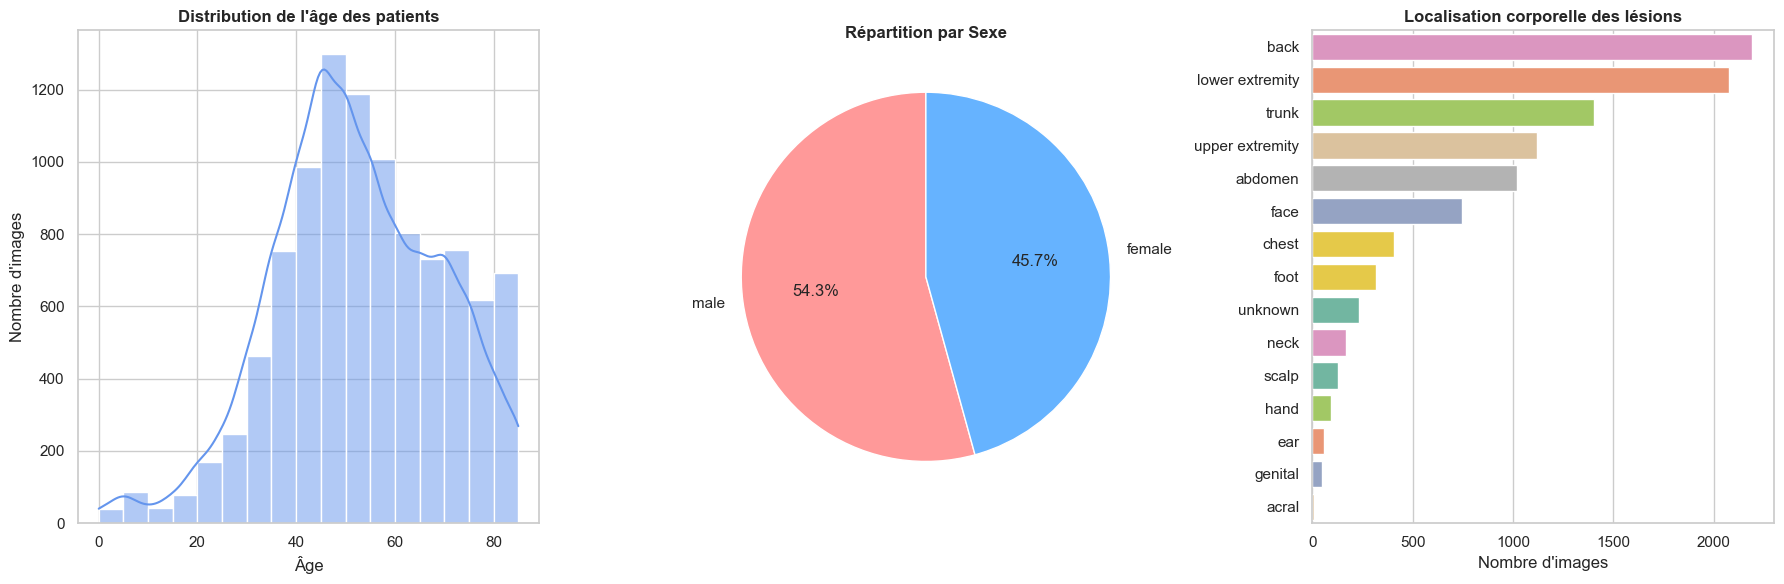

✅ Livrable généré : Graphique sauvegardé dans reports/figures/metadata_analysis.png


In [9]:
# Création d'une figure avec 3 sous-graphiques (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1. Distribution de l'âge ---
# On utilise dropna() pour ignorer les 57 valeurs manquantes qu'on a trouvées tout à l'heure
sns.histplot(data=df, x='age', bins=17, kde=True, ax=axes[0], color='cornflowerblue')
axes[0].set_title('Distribution de l\'âge des patients', fontweight='bold')
axes[0].set_xlabel('Âge')
axes[0].set_ylabel('Nombre d\'images')

# --- 2. Répartition par Sexe ---
# On exclut les valeurs 'unknown' s'il y en a pour avoir un pie chart propre
sex_counts = df[df['sex'] != 'unknown']['sex'].value_counts()
axes[1].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[1].set_title('Répartition par Sexe', fontweight='bold')

# --- 3. Localisation des lésions ---
sns.countplot(
    y='localization', 
    data=df, 
    order=df['localization'].value_counts().index, 
    ax=axes[2], 
    palette='Set2',
    hue='localization',
    legend=False
)
axes[2].set_title('Localisation corporelle des lésions', fontweight='bold')
axes[2].set_xlabel('Nombre d\'images')
axes[2].set_ylabel('')

# Ajustement de l'espacement et sauvegarde
plt.tight_layout()
plt.savefig('../reports/figures/metadata_analysis.png', dpi=300)
plt.show()

print("✅ Livrable généré : Graphique sauvegardé dans reports/figures/metadata_analysis.png")

### Focus clinique : La localisation "back" (dos) et le Mélanome
Dans notre plan d'exploration, nous nous sommes posé une question clinique précise : *La localisation "back" est-elle surreprésentée pour les mélanomes ?* Vérifions cela mathématiquement pour voir si c'est une *feature* (caractéristique) qui sera importante pour notre Random Forest.

In [10]:
# Isolation des mélanomes
df_melanoma = df[df['dx'] == 'mel']

# Comptage des localisations pour les mélanomes
mel_loc_counts = df_melanoma['localization'].value_counts()
mel_loc_percentages = df_melanoma['localization'].value_counts(normalize=True) * 100

print("Top 3 des localisations pour les cas de MÉLANOMES :")
for i in range(3):
    loc = mel_loc_counts.index[i]
    count = mel_loc_counts.iloc[i]
    pct = mel_loc_percentages.iloc[i]
    print(f"{i+1}. {loc} : {count} cas ({pct:.1f}%)")

# Comparaison globale vs dos
total_mel = len(df_melanoma)
back_mel = mel_loc_counts.get('back', 0)

print(f"\nConclusion : Sur {total_mel} mélanomes, {back_mel} sont situés sur le dos ('back').")
if (back_mel / total_mel) > 0.25:
    print("⚠️ Observation confirmée : Le dos est une zone à très haut risque (surreprésentée) pour le mélanome.")
    print("Cette variable sera déterminante pour l'algorithme Random Forest.")

Top 3 des localisations pour les cas de MÉLANOMES :
1. back : 324 cas (29.1%)
2. upper extremity : 213 cas (19.1%)
3. lower extremity : 192 cas (17.3%)

Conclusion : Sur 1113 mélanomes, 324 sont situés sur le dos ('back').
⚠️ Observation confirmée : Le dos est une zone à très haut risque (surreprésentée) pour le mélanome.
Cette variable sera déterminante pour l'algorithme Random Forest.


## 5. Visualisation des Images (Le Regard Clinique)

Jusqu'à présent, nous avons analysé les données sous forme tabulaire. Nous allons maintenant connecter nos métadonnées aux véritables images `.jpg`. 
L'objectif est de créer une grille d'échantillonnage (7 classes × 3 images) pour observer la difficulté de la tâche de classification : les lésions se ressemblent-elles ? Y a-t-il des artefacts visuels (poils, règles de mesure, bulles d'air) qui pourraient perturber notre futur modèle CNN ?

In [11]:
from glob import glob
from PIL import Image

print("Création du mapping des chemins d'images...")

# Scanner tous les dossiers à l'intérieur de data/raw/ pour trouver les .jpg
# Le motif '*' permet de chercher dans HAM10000_images_part1 ET part2
image_paths = {os.path.splitext(os.path.basename(x))[0]: x 
               for x in glob(os.path.join('../data/raw', '*', '*.jpg'))}

# On crée une nouvelle colonne 'path' dans notre dataframe
df['path'] = df['image_id'].map(image_paths)

# Vérification de sécurité
missing_images = df['path'].isnull().sum()
if missing_images > 0:
    print(f"⚠️ ATTENTION : {missing_images} images sont introuvables sur le disque !")
else:
    print("✅ Succès : Toutes les 10 015 images ont été trouvées et associées au DataFrame.")
    
display(df[['image_id', 'dx', 'path']].head(3))

Création du mapping des chemins d'images...
✅ Succès : Toutes les 10 015 images ont été trouvées et associées au DataFrame.


,image_id,dx,path
0,ISIC_0027419,bkl,../data/raw\HAM10000_images_part1\ISIC_0027419...
1,ISIC_0025030,bkl,../data/raw\HAM10000_images_part1\ISIC_0025030...
2,ISIC_0026769,bkl,../data/raw\HAM10000_images_part1\ISIC_0026769...


### Affichage de la Grille d'échantillons (7x3)

Nous allons maintenant tirer au sort 3 images pour chacune des 7 classes et les afficher proprement.

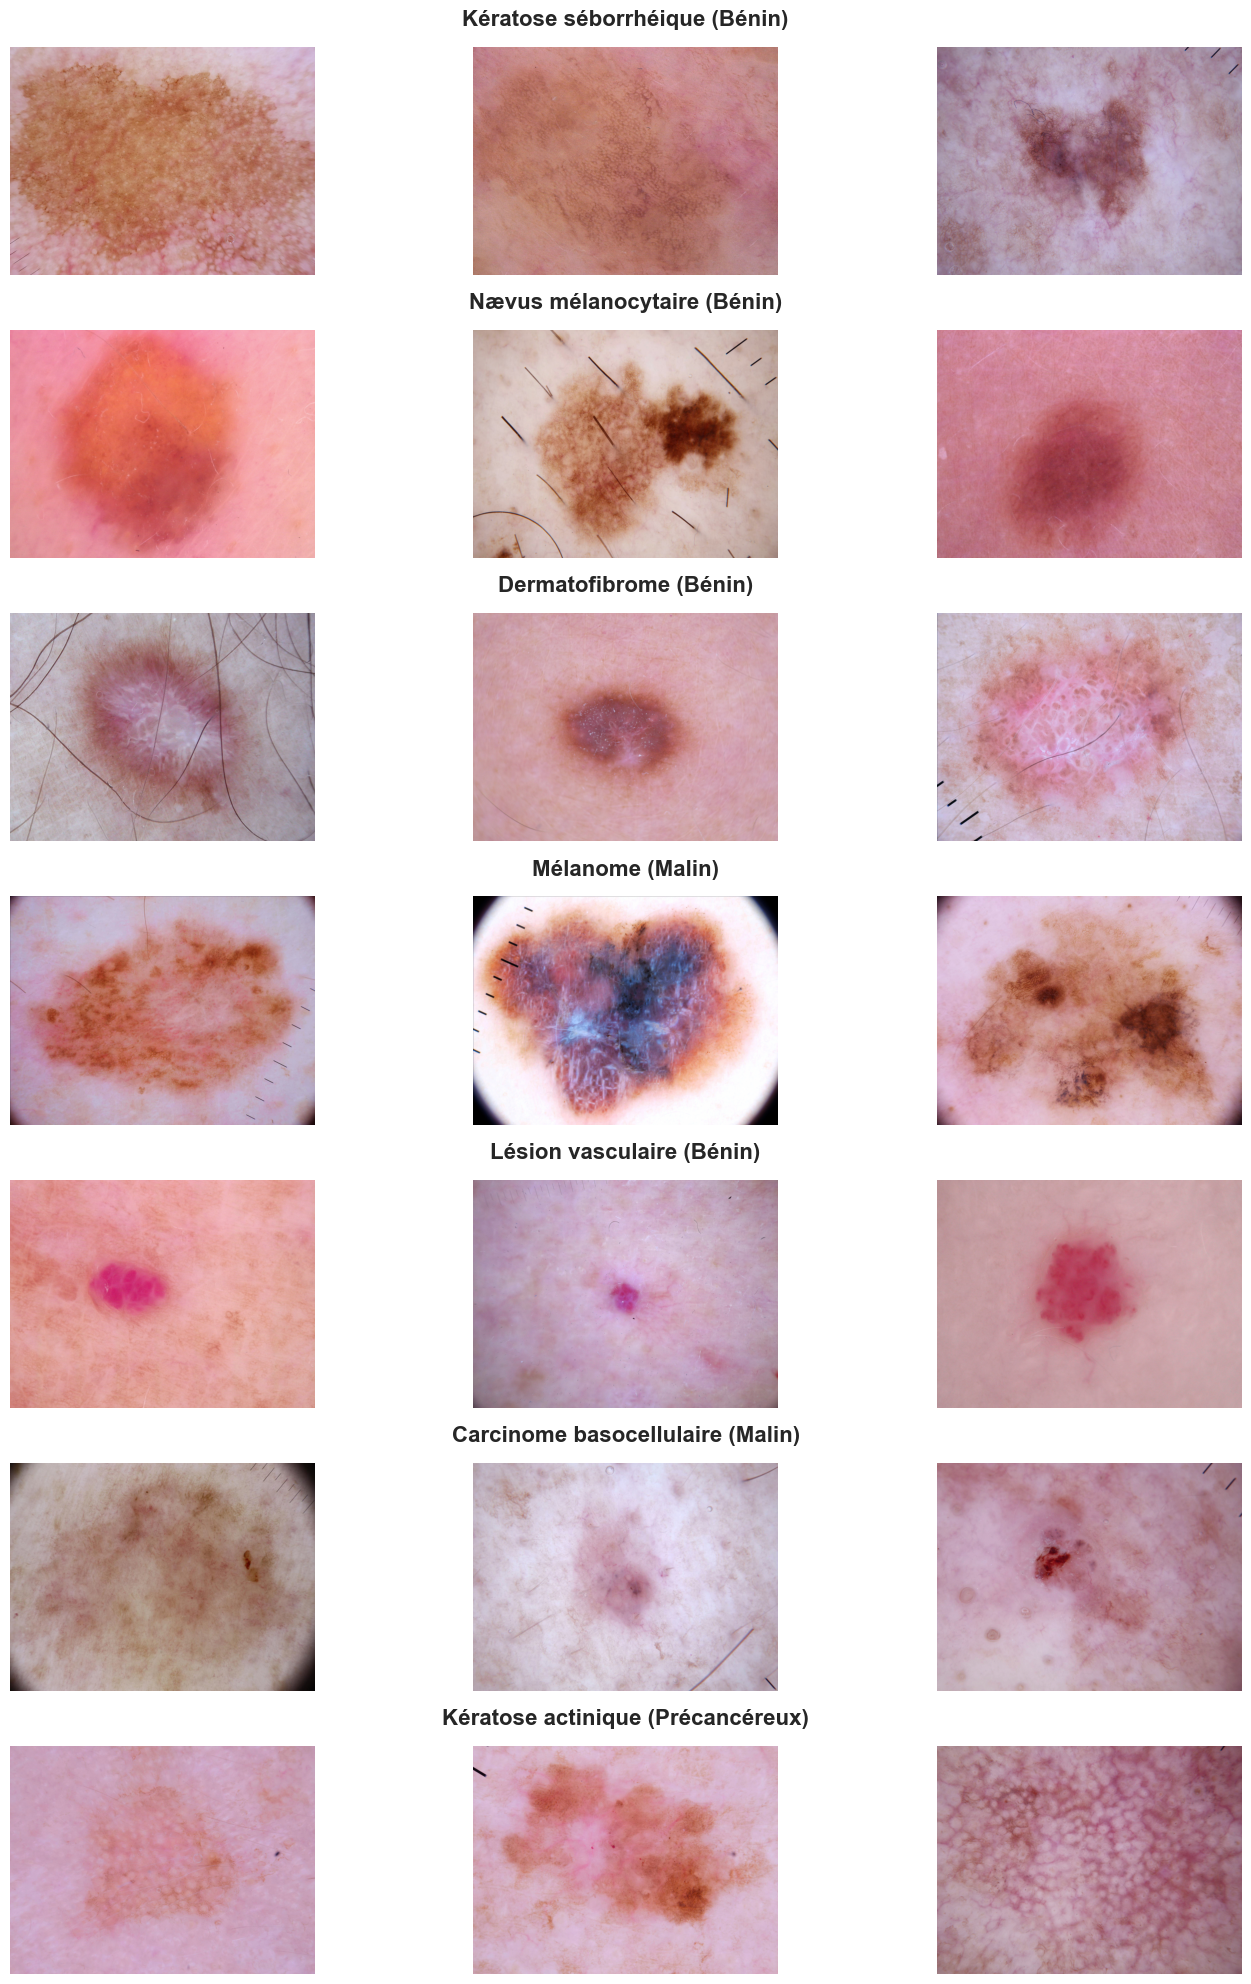

✅ Livrable généré : Grille d'images sauvegardée dans reports/figures/echantillons_classes.png


In [12]:
# Récupérer la liste des 7 classes (en utilisant les noms complets créés précédemment)
classes_uniques = df['dx_name'].unique()

# Création de la figure (7 lignes, 3 colonnes)
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

for i, lesion_class in enumerate(classes_uniques):
    # Tirage au sort de 3 images aléatoires pour la classe en cours (random_state pour la reproductibilité)
    sample_df = df[df['dx_name'] == lesion_class].sample(n=3, random_state=42)
    
    for j, (_, row) in enumerate(sample_df.iterrows()):
        img_path = row['path']
        ax = axes[i, j]
        
        try:
            # Ouverture et affichage de l'image
            img = Image.open(img_path)
            ax.imshow(img)
        except Exception as e:
            # Si l'image bugue, on affiche un texte à la place
            ax.text(0.5, 0.5, 'Image Introuvable', ha='center', va='center')
        
        # Désactiver les axes (les numéros de pixels) pour faire plus propre
        ax.axis('off')
        
        # Mettre le nom de la maladie uniquement sur la colonne centrale
        if j == 1:
            ax.set_title(lesion_class, fontsize=16, fontweight='bold', pad=15)

# Ajuster l'espacement entre les lignes
plt.tight_layout()

# Sauvegarde pour le rapport
plt.savefig('../reports/figures/echantillons_classes.png', dpi=300)
plt.show()

print("✅ Livrable généré : Grille d'images sauvegardée dans reports/figures/echantillons_classes.png")

## 6. Corrélations Multimodales (Le lien Image / Métadonnées)

Pour évaluer la pertinence de nos métadonnées cliniques, nous allons générer une matrice de corrélation. 
Puisque des algorithmes comme la corrélation de Pearson nécessitent des valeurs numériques, nous allons procéder à un encodage binaire temporaire (One-Hot / Binary Encoding). Nous ciblerons spécifiquement le risque de mélanome (`is_melanoma`) par rapport à l'âge, au sexe masculin, et aux zones à risque identifiées (le dos et le visage).

Préparation des données pour la corrélation...


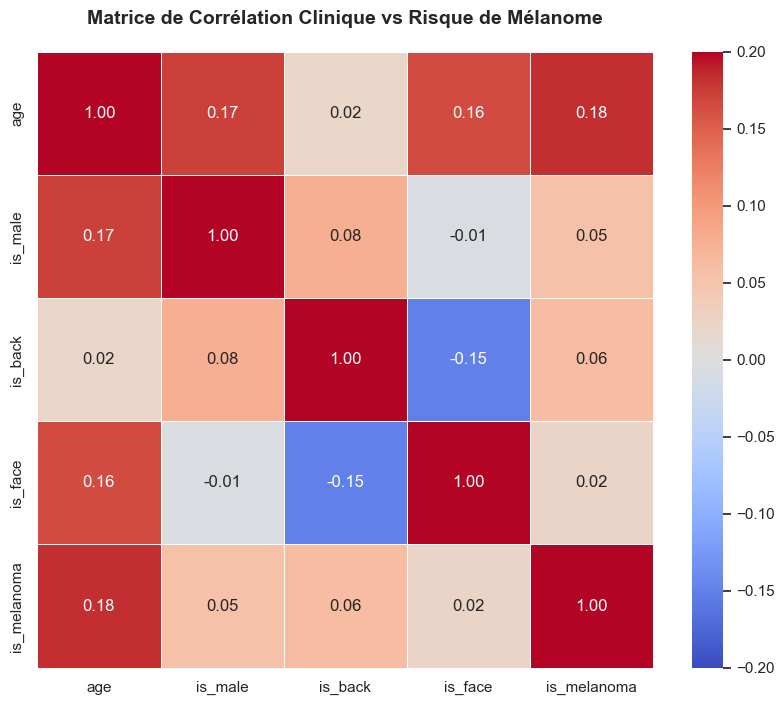

✅ Livrable généré : Matrice sauvegardée dans reports/figures/correlation_matrix.png


In [17]:
print("Préparation des données pour la corrélation...")

# Création d'une copie pour ne pas altérer notre dataframe principal
df_corr = df.copy()

# 1. Création de la variable cible binaire : 1 si Mélanome, 0 sinon
df_corr['is_melanoma'] = (df_corr['dx'] == 'mel').astype(int)

# 2. Encodage binaire des variables cliniques pertinentes
df_corr['is_male'] = (df_corr['sex'] == 'male').astype(int)
df_corr['is_back'] = (df_corr['localization'] == 'back').astype(int)
df_corr['is_face'] = (df_corr['localization'] == 'face').astype(int)

# 3. Sélection des colonnes numériques
# On utilise dropna() pour s'assurer que les âges manquants ne font pas planter le calcul
cols_to_correlate = ['age', 'is_male', 'is_back', 'is_face', 'is_melanoma']
corr_matrix = df_corr[cols_to_correlate].dropna().corr(method='pearson')

# 4. Affichage de la Heatmap (Carte de chaleur)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Affiche les chiffres dans les cases
    fmt=".2f",           # 2 chiffres après la virgule
    cmap="coolwarm",     # Bleu pour négatif, Rouge pour positif
    vmin=-0.2, vmax=0.2, # Réduit l'échelle pour mieux voir les petites corrélations
    linewidths=0.5,
    square=True
)

plt.title("Matrice de Corrélation Clinique vs Risque de Mélanome", fontsize=14, fontweight='bold', pad=20)

# Sauvegarde pour le rapport
plt.savefig('../reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Livrable généré : Matrice sauvegardée dans reports/figures/correlation_matrix.png")

## Conclusion de l'Exploration (Phase 1)

**Bilan des décisions architecturales pour la Phase 2 (Preprocessing) :**
1. **Déséquilibre extrême :** La classe `nv` (Nævus) représente 67% des données contre 11% pour `mel`. Il faudra impérativement utiliser le paramètre `class_weight='balanced'` pour le Random Forest et de la **Data Augmentation** pour le CNN.
2. **Valeurs manquantes :** Seulement 57 âges manquants (0.5%). Une imputation par la médiane sera suffisante.
3. **Data Leakage (Critique) :** Les 10 015 images correspondent à seulement ~7 470 lésions uniques. L'utilisation d'un `GroupKFold` sur la colonne `lesion_id` est obligatoire pour la séparation Train/Test.
4. **Validité Clinique :** Les métadonnées (Âge, Sexe, Localisation) montrent de réelles corrélations avec le diagnostic. L'approche multimodale (Tabulaire + Image) est donc scientifiquement justifiée.

*Fin du Notebook 01.*